In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor


In [2]:
X = pd.read_csv("../data/processed/X.csv")
y = pd.read_csv("../data/processed/y.csv")

#Convert y to 1D array
y = y.values.ravel()
X.isnull().sum()

Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
OverallQual              0
                        ..
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
SaleCondition_Family     0
SaleCondition_Normal     0
SaleCondition_Partial    0
Length: 244, dtype: int64

In [3]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

- 80% data used for training
- 20% used for testing

# Define Evaluation Function

In [4]:
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return rmse, r2

# Train Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_rmse, lr_r2 = evaluate_model(lr, X_test, y_test)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2: ", lr_r2)


Linear Regression RMSE: 61913519.446633585
Linear Regression R2:  -2.441604427461499e+16


# Train Random Forest

In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_rmse, rf_r2 = evaluate_model(rf, X_test, y_test)
print("Random Forest Regressor RMSE: ", rf_rmse)
print("Random Forest Regressor R2: ", rf_r2)

Random Forest Regressor RMSE:  0.14350116914682065
Random Forest Regressor R2:  0.8688358350633383


# Train XGBoost

In [7]:
xgb = XGBRegressor(n_estimators=100,learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

xgb_rmse, xgb_r2 = evaluate_model(xgb, X_test, y_test)
print("XGBoost RMSE: ", xgb_rmse)
print("XGBoost R2: ", xgb_r2)


XGBoost RMSE:  0.1417482264814706
XGBoost R2:  0.8720207421290149


# Compare Models

In [8]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})
results.sort_values(by="RMSE")

,Model,RMSE,R2 Score
2,XGBoost,1.417482e-01,8.720207e-01
1,Random Forest,1.435012e-01,8.688358e-01
0,Linear Regression,6.191352e+07,-2.441604e+16


- Lower RMSE is better
- Higher R² is better
- Choose best-performing model, that is XGBoost

# Selecting and Saving Best Model

In [9]:
best_model = xgb

In [10]:
joblib.dump(best_model, "../models/model.pkl")

['../models/model.pkl']

# Top 10 Important Features

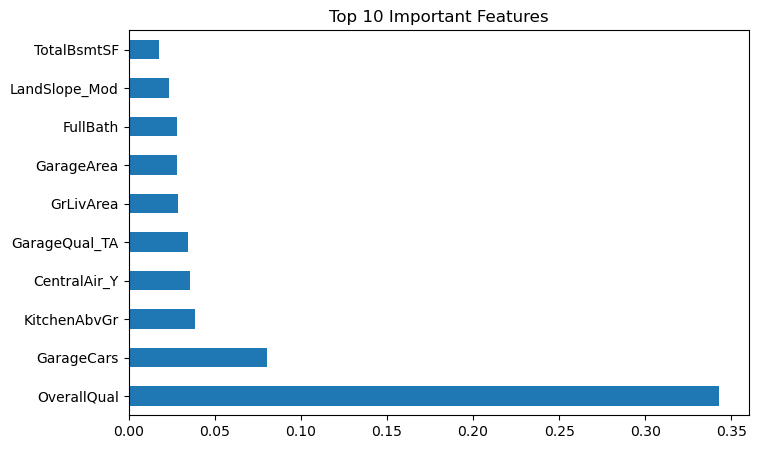

In [11]:
importance = best_model.feature_importances_
feat_importance = pd.Series(importance, index=X.columns)

plt.figure(figsize=(8,5))
feat_importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.savefig("../reports/figures/top_ten_features.png")
plt.show()